# Run adaptive immune system with noisy pMHCs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *
from joint_plot_grid_nb import *
import seaborn as sns

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

### (1) Plot sample trajectory

In [2]:
# Run single simulation
I_0 = 10000
b_I = 8
tau_I = 10
d_IE = 3.8*10**(-3)
T_I = 2

infection_type = "sec" #"prim", "sec"
sim_type = "agent" #"pop_ode", "agent"

# rates, I, N, E, cM, eM, T, ts = stoch_sim(I_0, b_I, tau_I, d_IE, 
#                                     noise_model = "pop", 
#                                     noise_cv = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
#                                     infection = infection_type)

regs, I, N, E, cM, eM, eTr, ts = agent_stoch_sim(I_0 = I_0, b_I = b_I, tau_I = tau_I, d_IE = d_IE, T_I = T_I,
                    infection = infection_type)

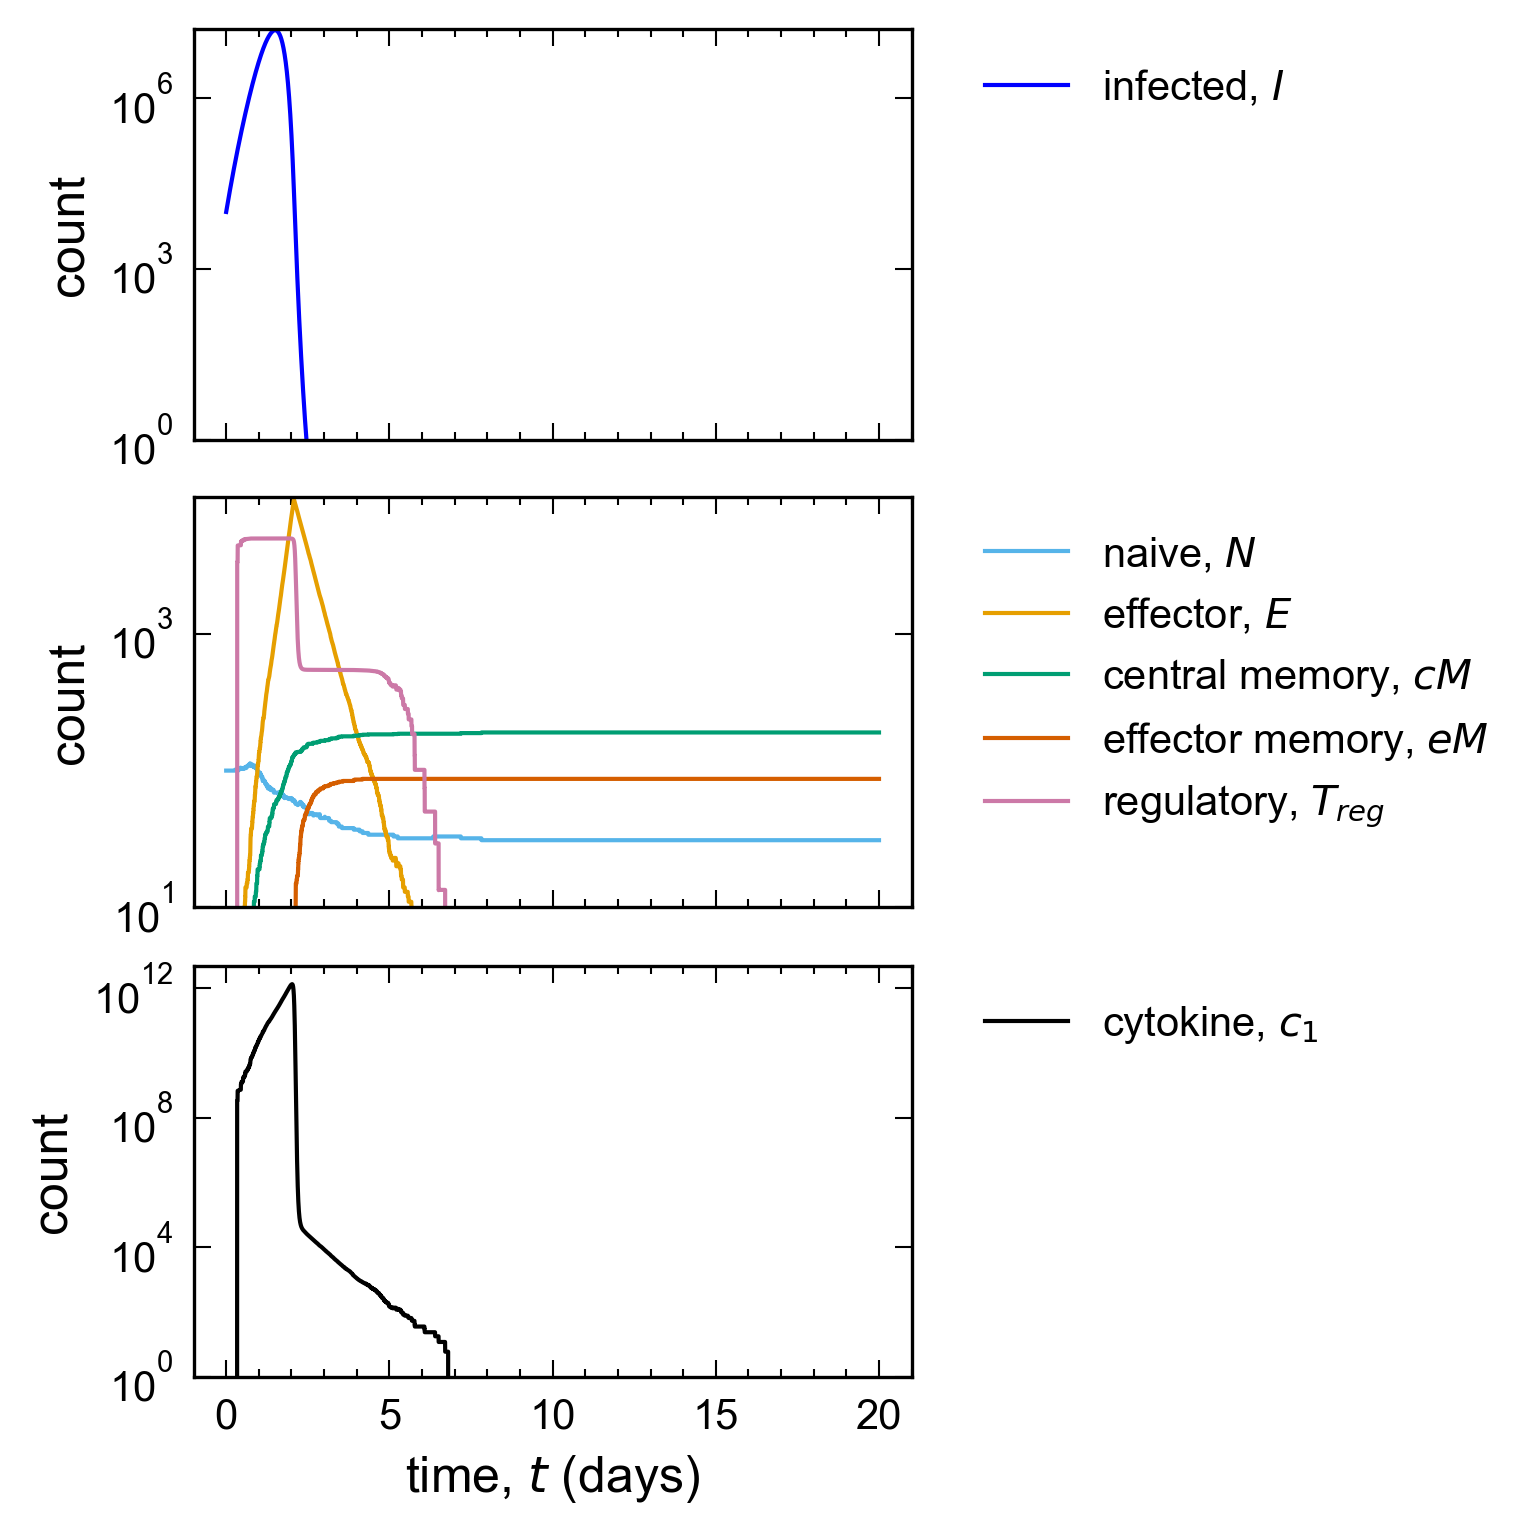

In [3]:
# Plot simulated outputs
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = True, figsize=(5,5))

ax1.plot(ts, I, 'b', label = r'infected, $I$')
ax1.set(ylabel='count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, N, label = r'naive, $N$')
ax2.plot(ts, E, label = r'effector, $E$')
ax2.plot(ts, cM, label = r'central memory, $cM$')
ax2.plot(ts, eM, label = r'effector memory, $eM$')
ax2.plot(ts, eTr, label = r'regulatory, $T_{reg}$')
ax2.set(ylabel='count')
ax2.set_ylim(10,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, c1_ss.py_func(p_A(tau_I,I),tau_I,I, E, eTr),'k-', label = r'cytokine, $c_1$')
#ax3.plot(ts, c1_ss(P1.py_func(I, E)[0], E, T)/k_E,'k-', label = r'$\frac{c_1}{k_E}$')
#ax3.plot(ts, c2_ss(I,E),'k-.', label = r'$c_2$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='count')
ax3.semilogy()
ax3.set_ylim(1,)
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig("_figs/"+infection_type+'-'+'virus-effector dynamics.eps', dpi=300, bbox_inches="tight")

Text(0.5, 0.98, 'Peak response response: $\\tau_I=$ 10, $b_I=$8')

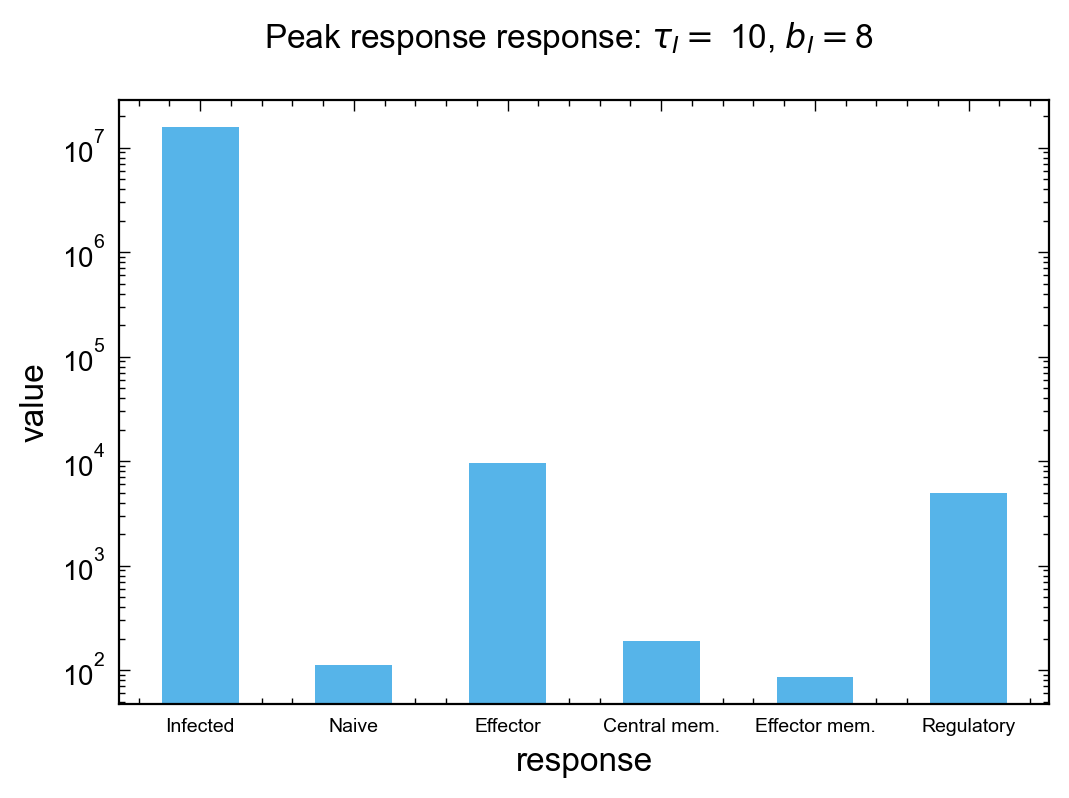

In [4]:
# Compute max values in the data
r = np.arange(6)
width = 0.5
plt.bar(r, np.amax(np.array([I, N, E, cM, eM, eTr]).T, axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r, ["Infected","Naive","Effector","Central mem.","Effector mem.", "Regulatory"], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Peak response response: $\tau_I=$ '+str(tau_I) +r', $b_I=$'+str(b_I))
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'peak-response'+'.png', dpi=150)

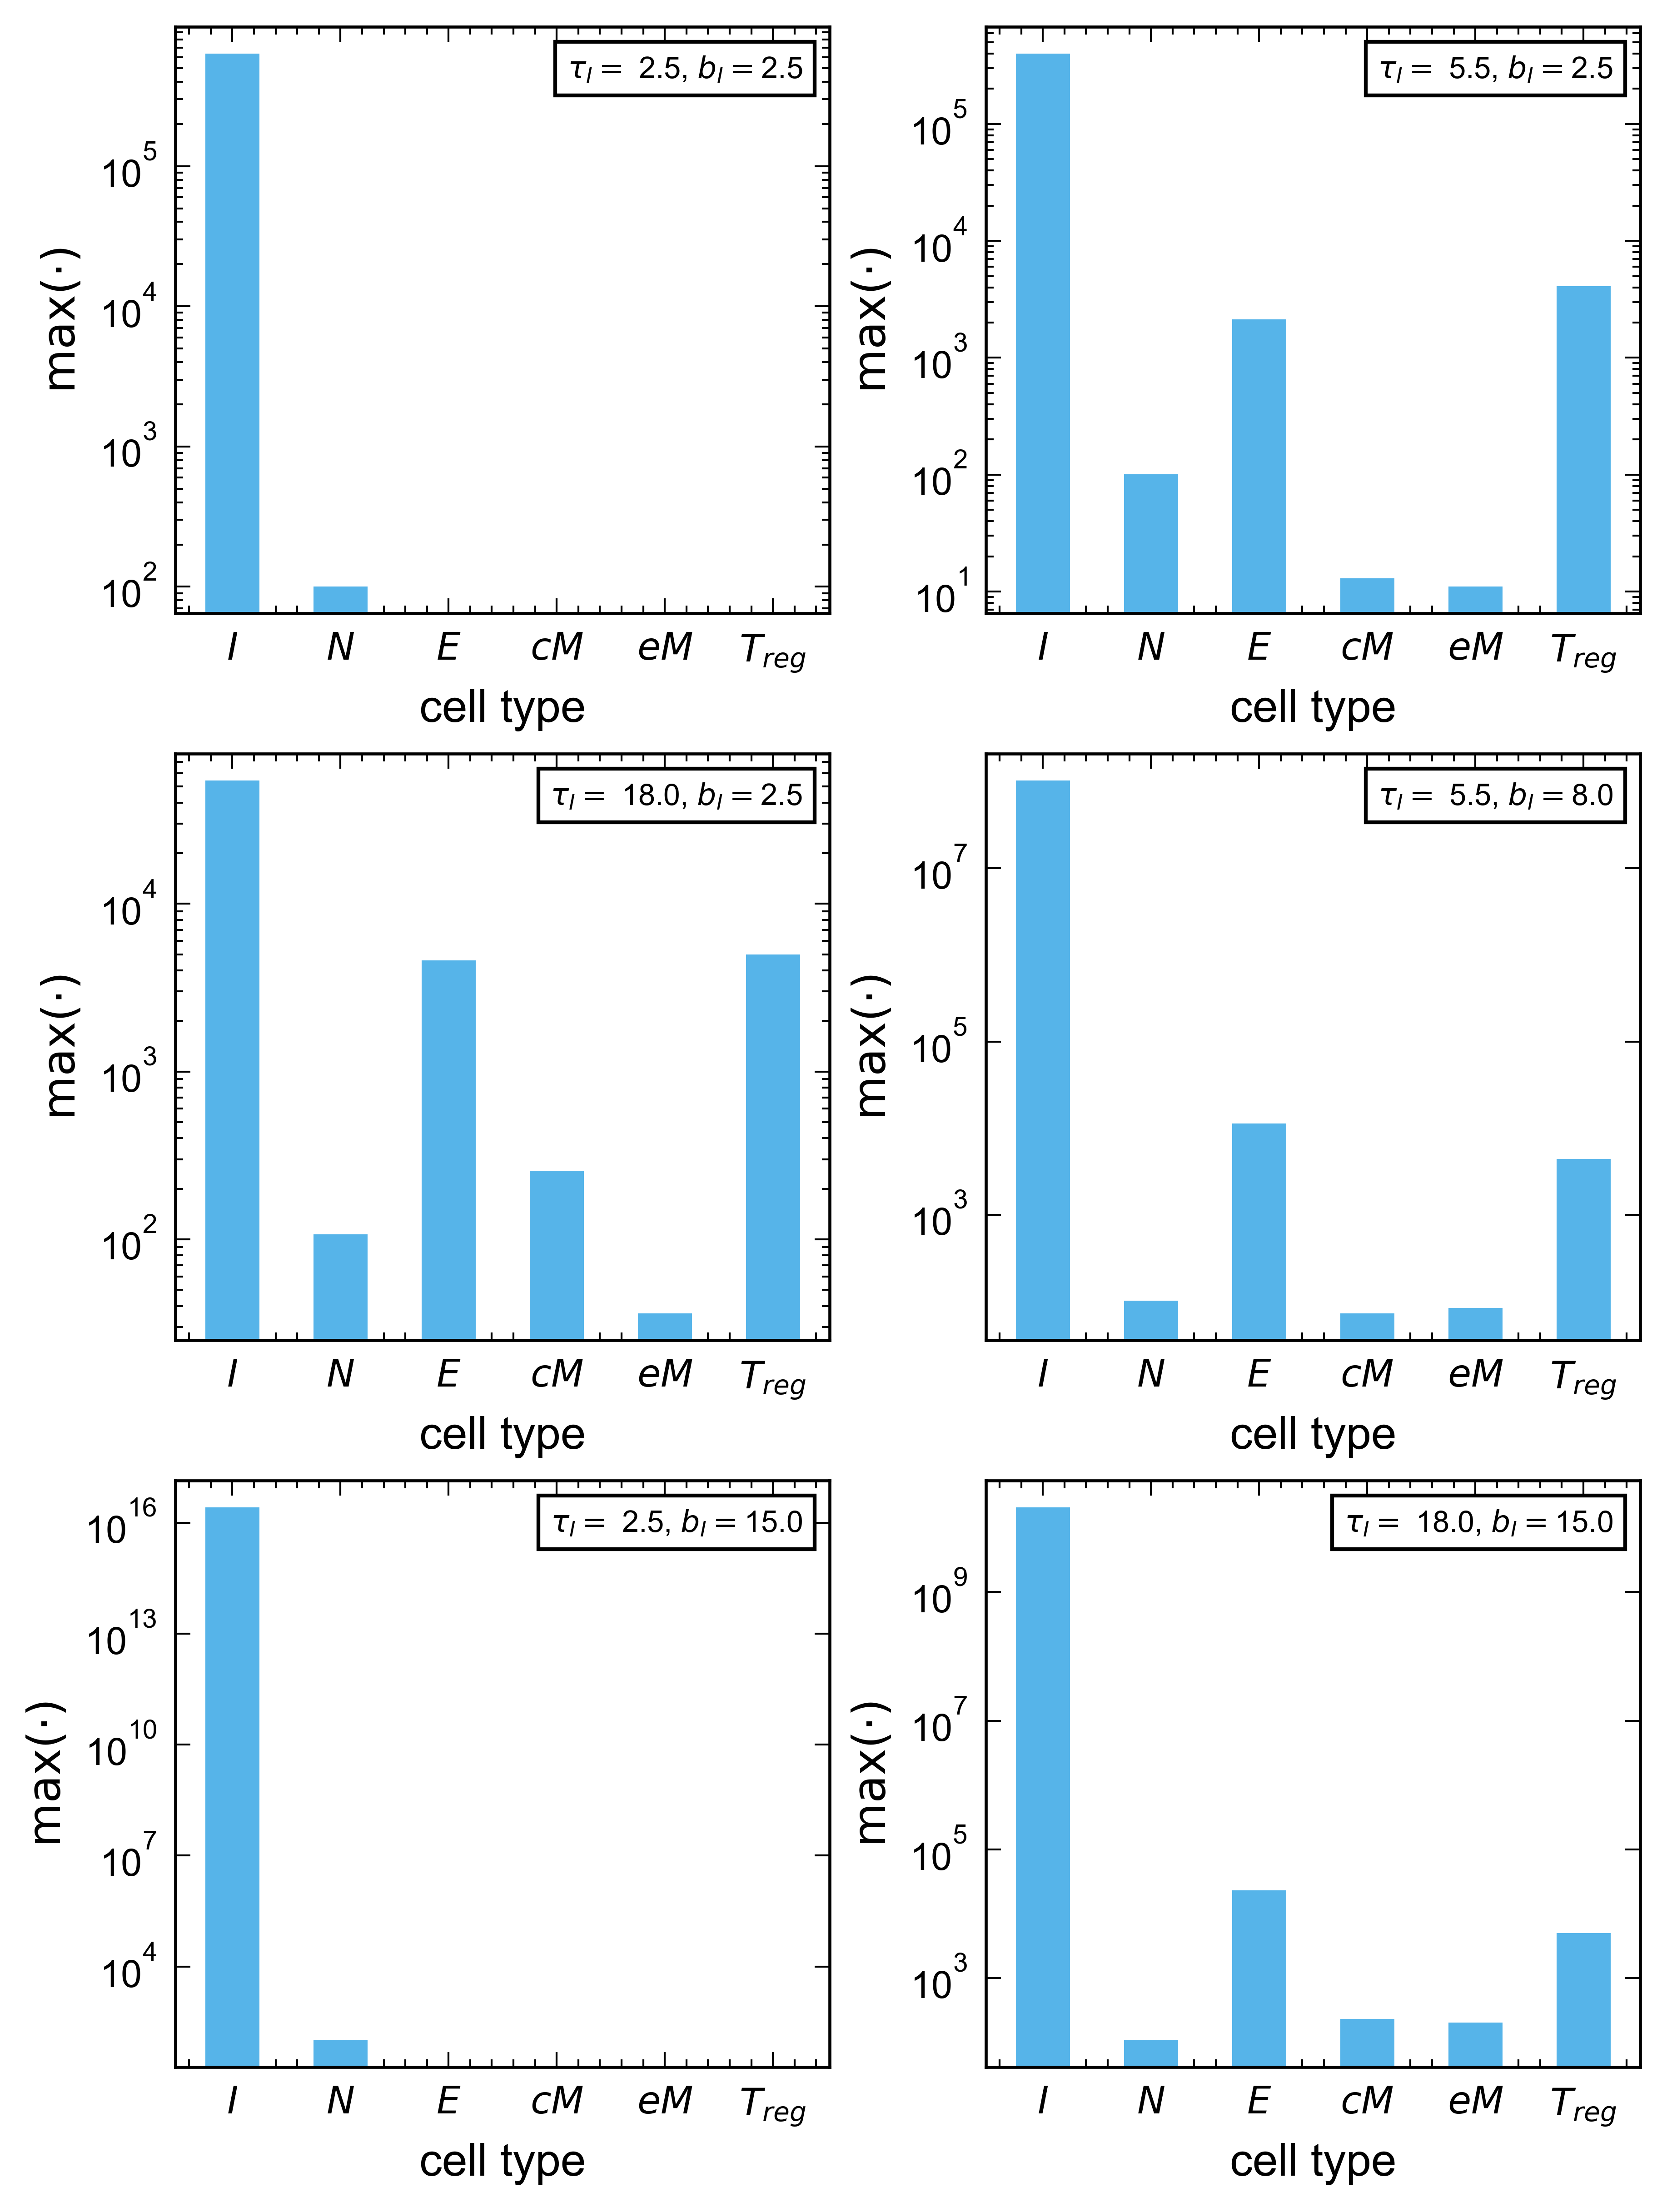

In [5]:
# Plot ranking MI of networks
from matplotlib.offsetbox import AnchoredText
fig, axs = plt.subplots(3,2, dpi = 300, constrained_layout = True, figsize = (6,8))

b_Is = np.array([2.5, 2.5, 2.5, 8.0, 15.0, 15.0])
tau_Is = np.array([2.5, 5.50, 18.0, 5.50, 2.5, 18.0])

for i, ax in enumerate(axs.flat):
    
    regs, I, N, E, cM, eM, eTr, ts = agent_stoch_sim(I_0 = I_0, b_I = b_Is[i], tau_I = tau_Is[i], d_IE = d_IE, T_I = T_I,
                    infection = infection_type)
    #response = np.sum( np.log( np.maximum(np.array([I, N, E, cM, eM, eTr]), 1) ), axis = 1)*(ts[1]-ts[0])
    response = np.amax(np.array([I, N, E, cM, eM, eTr]), axis =1)
    
    anchored_text = AnchoredText(r'$\tau_I=$ '+str(tau_Is[i]) +r', $b_I=$'+str(b_Is[i]), 
                                 prop=dict(size=8), loc = "upper right")
    
    r = np.arange(6)
    width = 0.5
    ax.bar(r, response, width = width, label = r'vary $\tau_I$')
    ax.semilogy()
    #ax.set(ylabel = r"$\int_0^{T_{sim}}\log(\cdot)dt$", xlabel = 'cell type')
    ax.set(ylabel = r"$\max(\cdot)$", xlabel = 'cell type')
    ax.set_xticks(r)
    ax.set_xticklabels([r"$I$", r"$N$", r"$E$", r"$cM$", r"$eM$", r"$T_{reg}$"])
    ax.add_artist(anchored_text)
    
fig.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'responses-in-pathogen-regimes.png', dpi=300)

In [6]:
# fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(5,5), sharex=True, dpi=150)

# # This sets how many simulations are performed.
# num_realizations = 50
# plot_labels = [r"$I$", r"$N$", r"$E$", r"$cM$", r"$eM$"]

# trajectories = np.zeros(shape=(num_realizations, 5, steps+1))
# for idx in range(num_realizations):
#     _, I, N, E, cM, eM, T, ts = stoch_sim(infection = infection_type)

#     trajectories[idx] = I, N, E, cM, eM
# print(trajectories.shape)
# # Filter out the entries in the numpy array which were full of zeros
# # so they aren't plotted.
# where_nonzero = np.count_nonzero(trajectories, axis=2).sum(axis=1) != 0
# trajectories = trajectories[where_nonzero]

# # Compute the mean and standard deviation over all the rows at each column.
# # Plot the mean as a solid line and the mean +/- std as fill.
# for states, ax in enumerate(axes):
#     means = np.mean(trajectories[:,states,:], axis=0)
#     stds = np.std(trajectories[:,states,:], axis=0)
#     ax.plot(ts, means, 'k-')
#     #ax.semilogy()
#     ax.fill_between(ts, means - stds, means + stds, alpha=0.3)

# # Make legend appear.
# # for ax in axes:
# #     ax.legend(fontsize=11, frameon=False, loc='upper right') #, bbox_to_anchor=(1.0,0.5))    

# # Set xlabel.
# for states, ax in enumerate(axes):
#     if states == 4:
#         ax.set_xlabel('time, $t$', fontsize=13)
    
# # Set ylabels.
# ylabels = plot_labels
# for ax, ylabel in zip(axes, ylabels):
#     ax.set_ylabel(ylabel, fontsize=13)

# # Align y-axis labels.
# fig.align_ylabels(axes)

# fig.tight_layout()
# plt.show()
# fig.savefig("_figs/"+infection_type+'-'+'population-virus-effector dynamics.png', dpi=150, bbox_inches="tight")

## (2) Parallelize simulation runs

In [7]:
# Parallelize simulation runs
def for_parallel(I_params,
                 rate_cv = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 2.0],
                 sim_kind = sim_type):
    
    return sum_sim(b_I = I_params[0], tau_I = I_params[1],
                   regulation_coeffs = [0.5, 0.5, 0.5, 0.5, 1.0, 0.0],
                   rate_cv = rate_cv, infection = infection_type, sim_kind = sim_kind)

In [8]:
# Set global simulation parameters
runs = 500

In [9]:
# run several simulations varying b_I,tau_I indep, logNorm()
cv_b_I, cv_tau_I = 0.5, 0.5

# Is = np.random.lognormal(mean = np.log(np.array([b_I, tau_I])/np.sqrt(1 + np.array([cv_b_I, cv_tau_I])**2)), 
#                             sigma = np.sqrt(np.log(1 + np.array([cv_b_I, cv_tau_I])**2)), size = (runs,2))

Is = np.random.uniform(low = np.array([0.01, 0.5]), 
                            high = np.array([2*b_I, 2*tau_I]), size = (runs,2))

run_data = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=max(int(len(Is)/8),1))(delayed(for_parallel)(I_params = I_params)
                                              for I_params in Is), dtype=object)

## (3) Plot distribution of response statistics from simulations varying $b_{I}$ and $\tau_I$

In [10]:
run_rates = np.zeros((runs, len(run_data[:,0][0]) ))
run_data_Is = np.zeros((runs, len(run_data[:,1][0]) ))

for i in np.arange(0,runs):
    run_rates[i,:] = run_data[:,0][i]
    run_data_Is[i,:] = run_data[:,1][i]

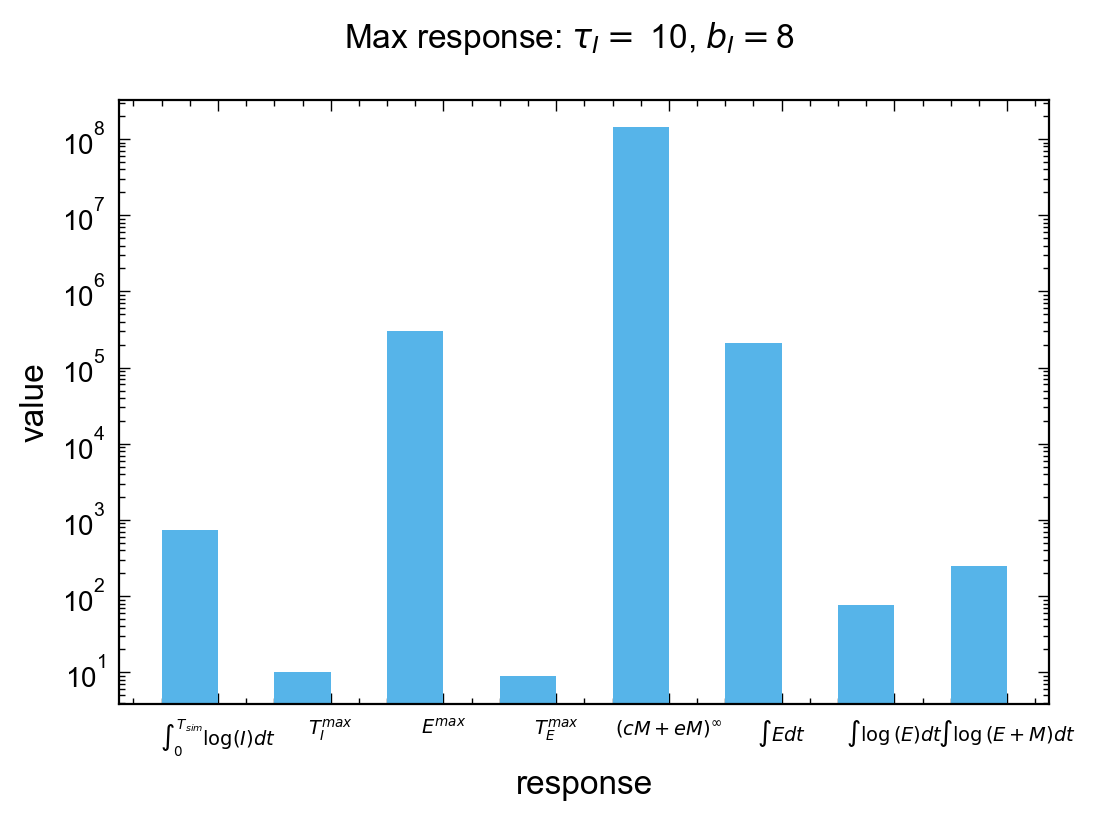

In [11]:
# Compute max values in the data
r = 2*np.arange(len(stat_names)-10)
width = 1
plt.bar(r, np.amax(run_data_Is[:,10:], axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + width/2,stat_names[10:], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Max response: $\tau_I=$ '+str(tau_I) +r', $b_I=$'+str(b_I))
plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-max'+'.png', dpi=150)

[5.00000000e-01 5.00000000e-01 5.00000000e-01 5.00000000e-01
 1.00000000e+00 0.00000000e+00 1.00000000e+04 8.43374396e-02
 1.62687692e+01 3.80000000e-04 1.04207864e+02 0.00000000e+00
 1.19310000e+04 1.99000000e+00 4.44000000e+02 8.88540800e+03
 3.19352598e+01 1.23343912e+02]
[5.00000000e-01 5.00000000e-01 5.00000000e-01 5.00000000e-01
 1.00000000e+00 0.00000000e+00 1.00000000e+04 1.58900657e+01
 1.71274189e+01 3.80000000e-04 5.81667735e+01 2.07800000e+00
 3.01596000e+05 2.70600000e+00 2.91400000e+03 2.12495266e+05
 5.57757701e+01 1.61566838e+02]
[0.5 0.5 0.5 0.5 1.  0. ]


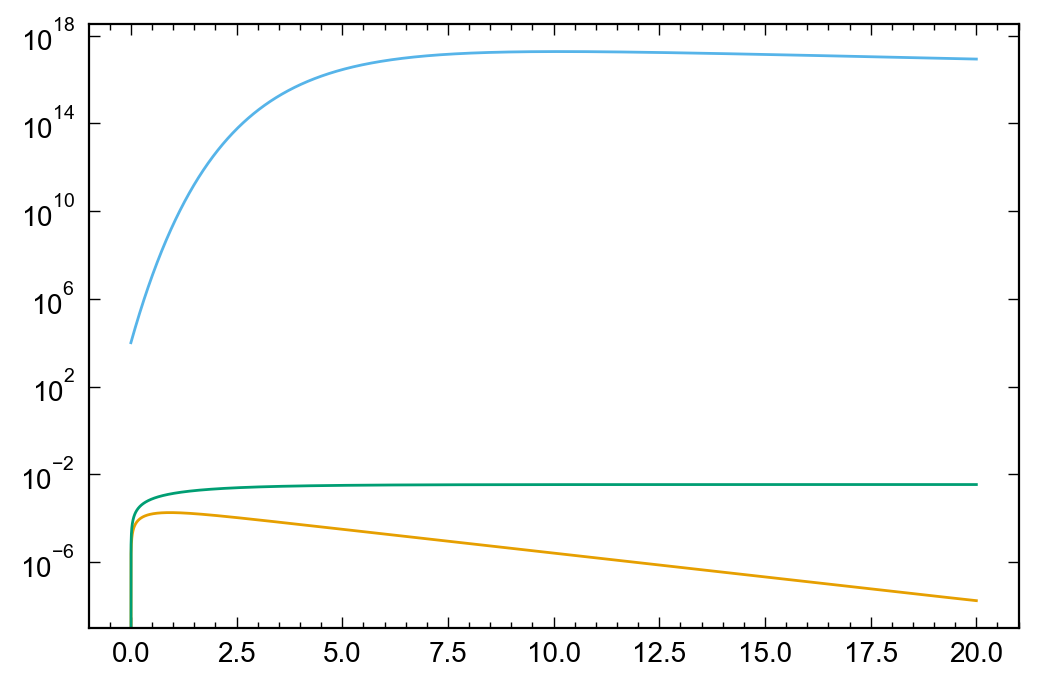

In [12]:
# # Troubleshooting outliers
print(run_data_Is[np.argmin(run_data_Is[:, 11]),:])
print(run_data_Is[np.argmax(run_data_Is[:, 15]),:])
immune_param= run_rates[np.argmax(run_data_Is[:, 15]), :]
virus_param = (run_data_Is[np.argmax(run_data_Is[:, 15]), :])[6:10]

rates, I, N, E, cM, eM, T, ts = stoch_sim(virus_param[0], virus_param[1], virus_param[2], virus_param[3],
                                          rates = immune_param,
                                          noise_model = "pop", 
                                          rate_cv = [0.0, 0.0, 0.0, 0.0],
                                          infection = infection_type)

plt.plot(ts,np.array([I, E, cM]).T)
plt.semilogy()
# plt.plot(ts,np.array([p_A(tau_I,I)]).T)

print(immune_param)

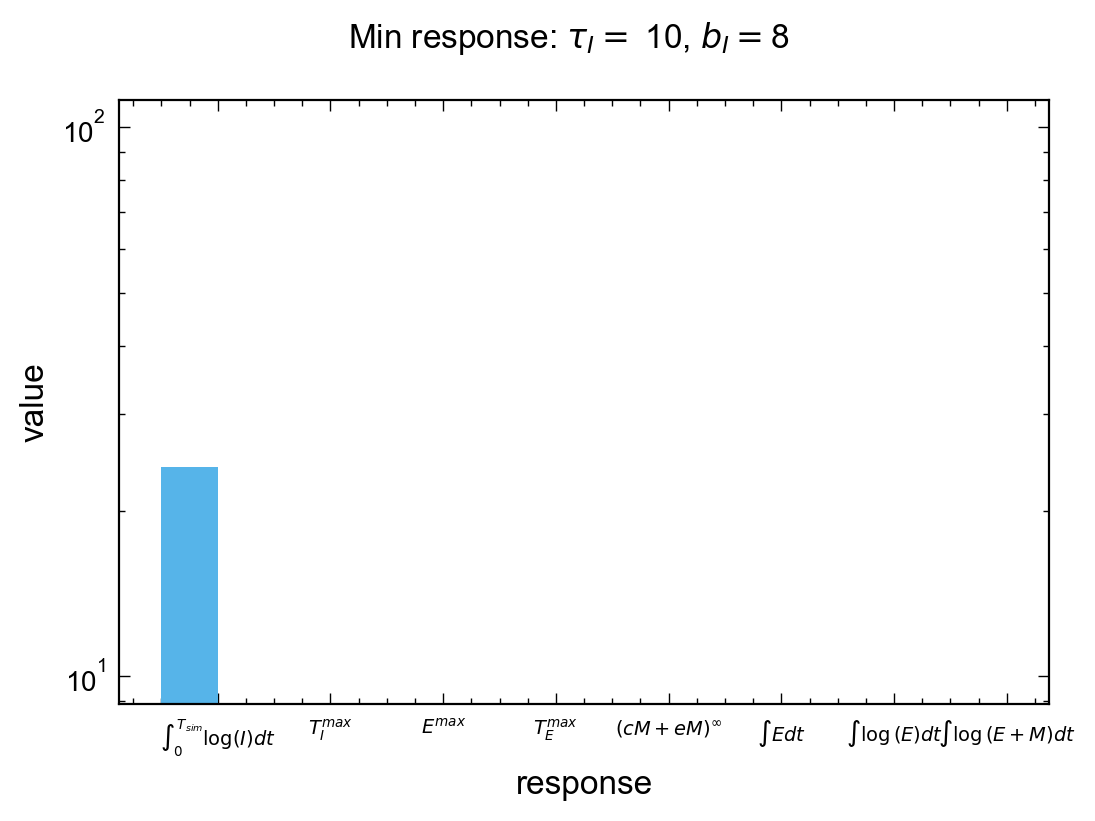

In [13]:
# Compute minimum values in the data
r = 2*np.arange(len(stat_names)-10)
width = 1
plt.bar(r, np.amin(run_data_Is[:,10:], axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + width/2,stat_names[10:], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Min response: $\tau_I=$ '+str(tau_I) +r', $b_I=$'+str(b_I))
plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-min'+'.png', dpi=150)

## (4) Compute mutual information between variables

In [14]:
# compute mutual information
MI_b_I = np.zeros(run_data_Is.shape[1])
for i in np.hstack(([7],np.arange(10,len(stat_names)))):
    MI_b_I[i] = calc_MI(run_data_Is[:,7],run_data_Is[:,i])

MI_tau_I = np.zeros(run_data_Is.shape[1])
for i in np.hstack(([8],np.arange(10,len(stat_names)))):
    MI_tau_I[i] = calc_MI(run_data_Is[:,8],run_data_Is[:,i])

Text(0.5, 0.98, 'Entropy in generated data')

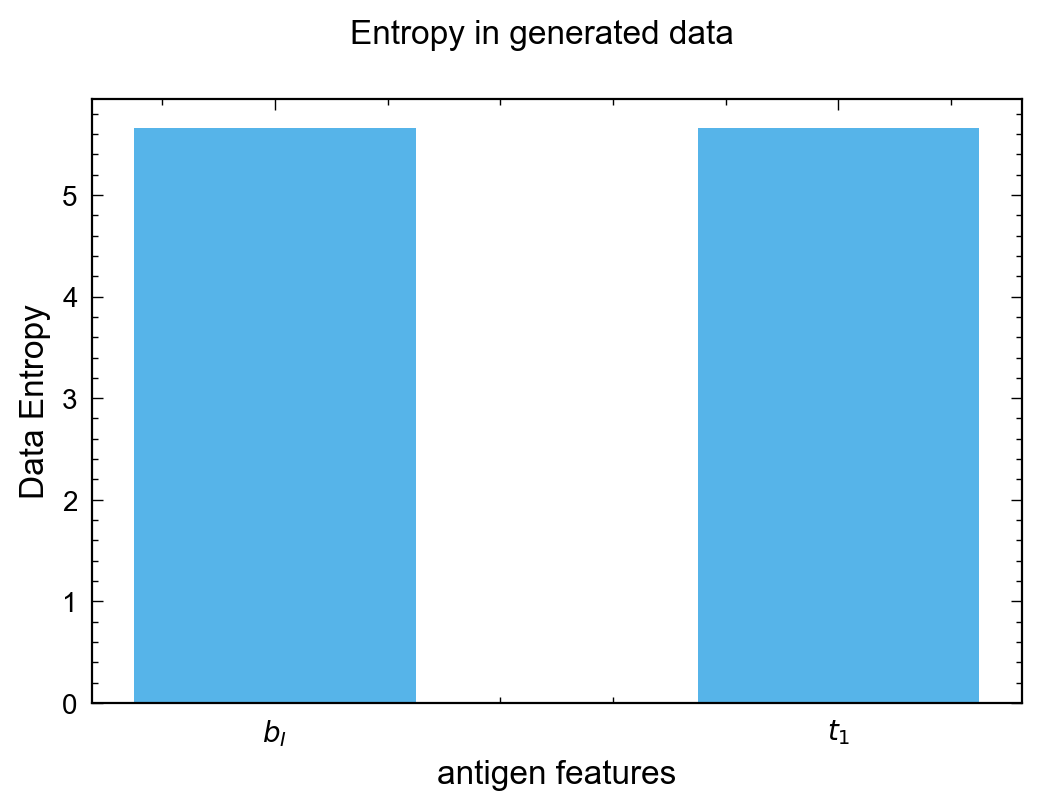

In [15]:
# Plot Data Entropy
plt.figure(1)

r = np.arange(2)
width = 0.5
plt.bar(r, np.array([MI_b_I[7],MI_tau_I[8]]), width = width)

plt.xlabel("antigen features")
plt.ylabel("Data Entropy")

plt.xticks(r,stat_names[7:9])
plt.suptitle(r'Entropy in generated data')
#plt.savefig("_figs/"+infection_type+'-'+'response-mutual-info-gauss-tau_I-'+str(tau_I)+'.png', dpi=150, bbox_inches="tight")

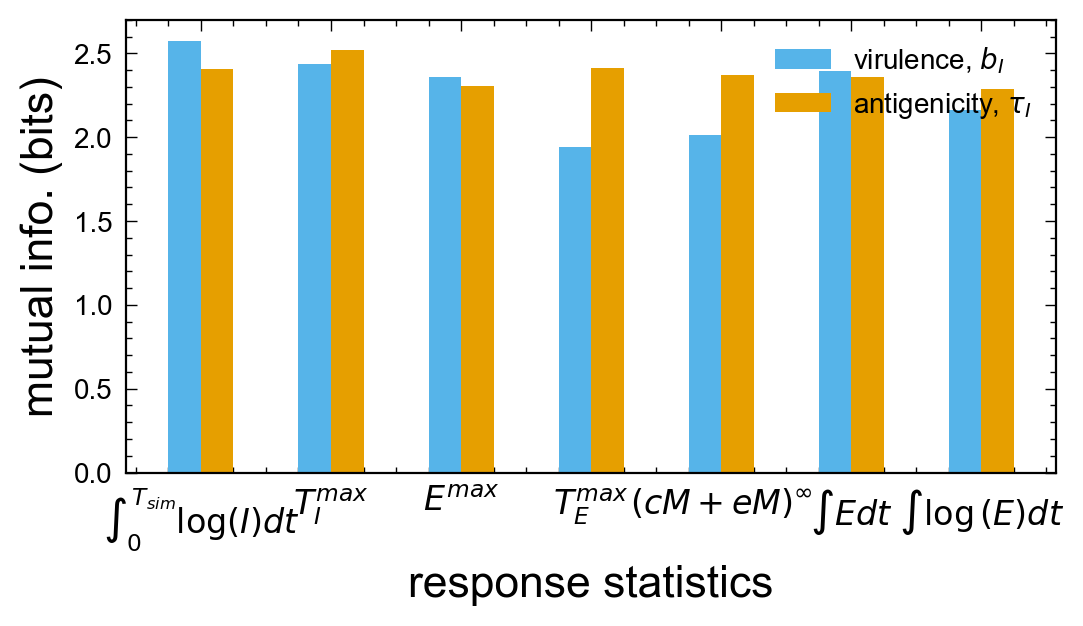

In [16]:
# Plot mutual information
plt.figure(figsize=(6,3))

r = 2*np.arange(len(MI_b_I[10:-1]))
width = 0.5
plt.bar(r, MI_b_I[10:-1], width = width, label = r'virulence, $b_{I}$')
plt.bar(r + width, MI_tau_I[10:-1], width = width, label = r'antigenicity, $\tau_I$')


plt.xlabel("response statistics", fontsize = 16)
plt.ylabel("mutual info. (bits)", fontsize = 16)

plt.xticks(r + width/2,stat_names[10:-1],fontsize=12)
plt.legend(loc='upper right')
#plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
#plt.suptitle(r'MI (bits) between $b_{I}, \tau_I,$ and response')
plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-mutual-info.png', dpi=300, bbox_inches="tight")

## (5) Plot trajectories from simulations

In [17]:
# Plot trajectories for b_I

# fig_b_I.suptitle(r'Immune response varying $b_{a_1}$ (Gaussian), $\tau_I=$ '+str(tau_I))
# plt.show()
# fig_b_I.savefig('plot-response-varying-b_I-gauss-tau_I-'+str(tau_I)+'.png', dpi=150)
ylabels=stat_names[10:]
xlabels = [stat_names[7]]*len(ylabels)

fig_b_I = joint_plot_grid([run_data_Is[:,7]]* len(ylabels), run_data_Is[:,10:].T.tolist(), granularity=50,
                use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_b_I.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'plot-response-varying-b_I.png', dpi=150,bbox_inches="tight")


/opt/anaconda3/lib/python3.9/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/opt/anaconda3/lib/python3.9/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


In [18]:
# Plot trajectories for tau_I
# fig_tau_I.suptitle(r'Immune response while varying $\tau_I$ (Gaussian), $\tau_I=$ '+str(tau_I))
# plt.show()
# fig_tau_I.savefig('plot-response-varying-tau_I-gauss-tau_I-'+str(tau_I)+'.png', dpi=150)
ylabels=stat_names[10:]
xlabels = [stat_names[8]]*len(ylabels)

fig_tau_I = joint_plot_grid([run_data_Is[:,8]]*len(ylabels), run_data_Is[:,10:].T.tolist(), granularity=50, use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_tau_I.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'plot-response-varying-tau_I.png', dpi=150)

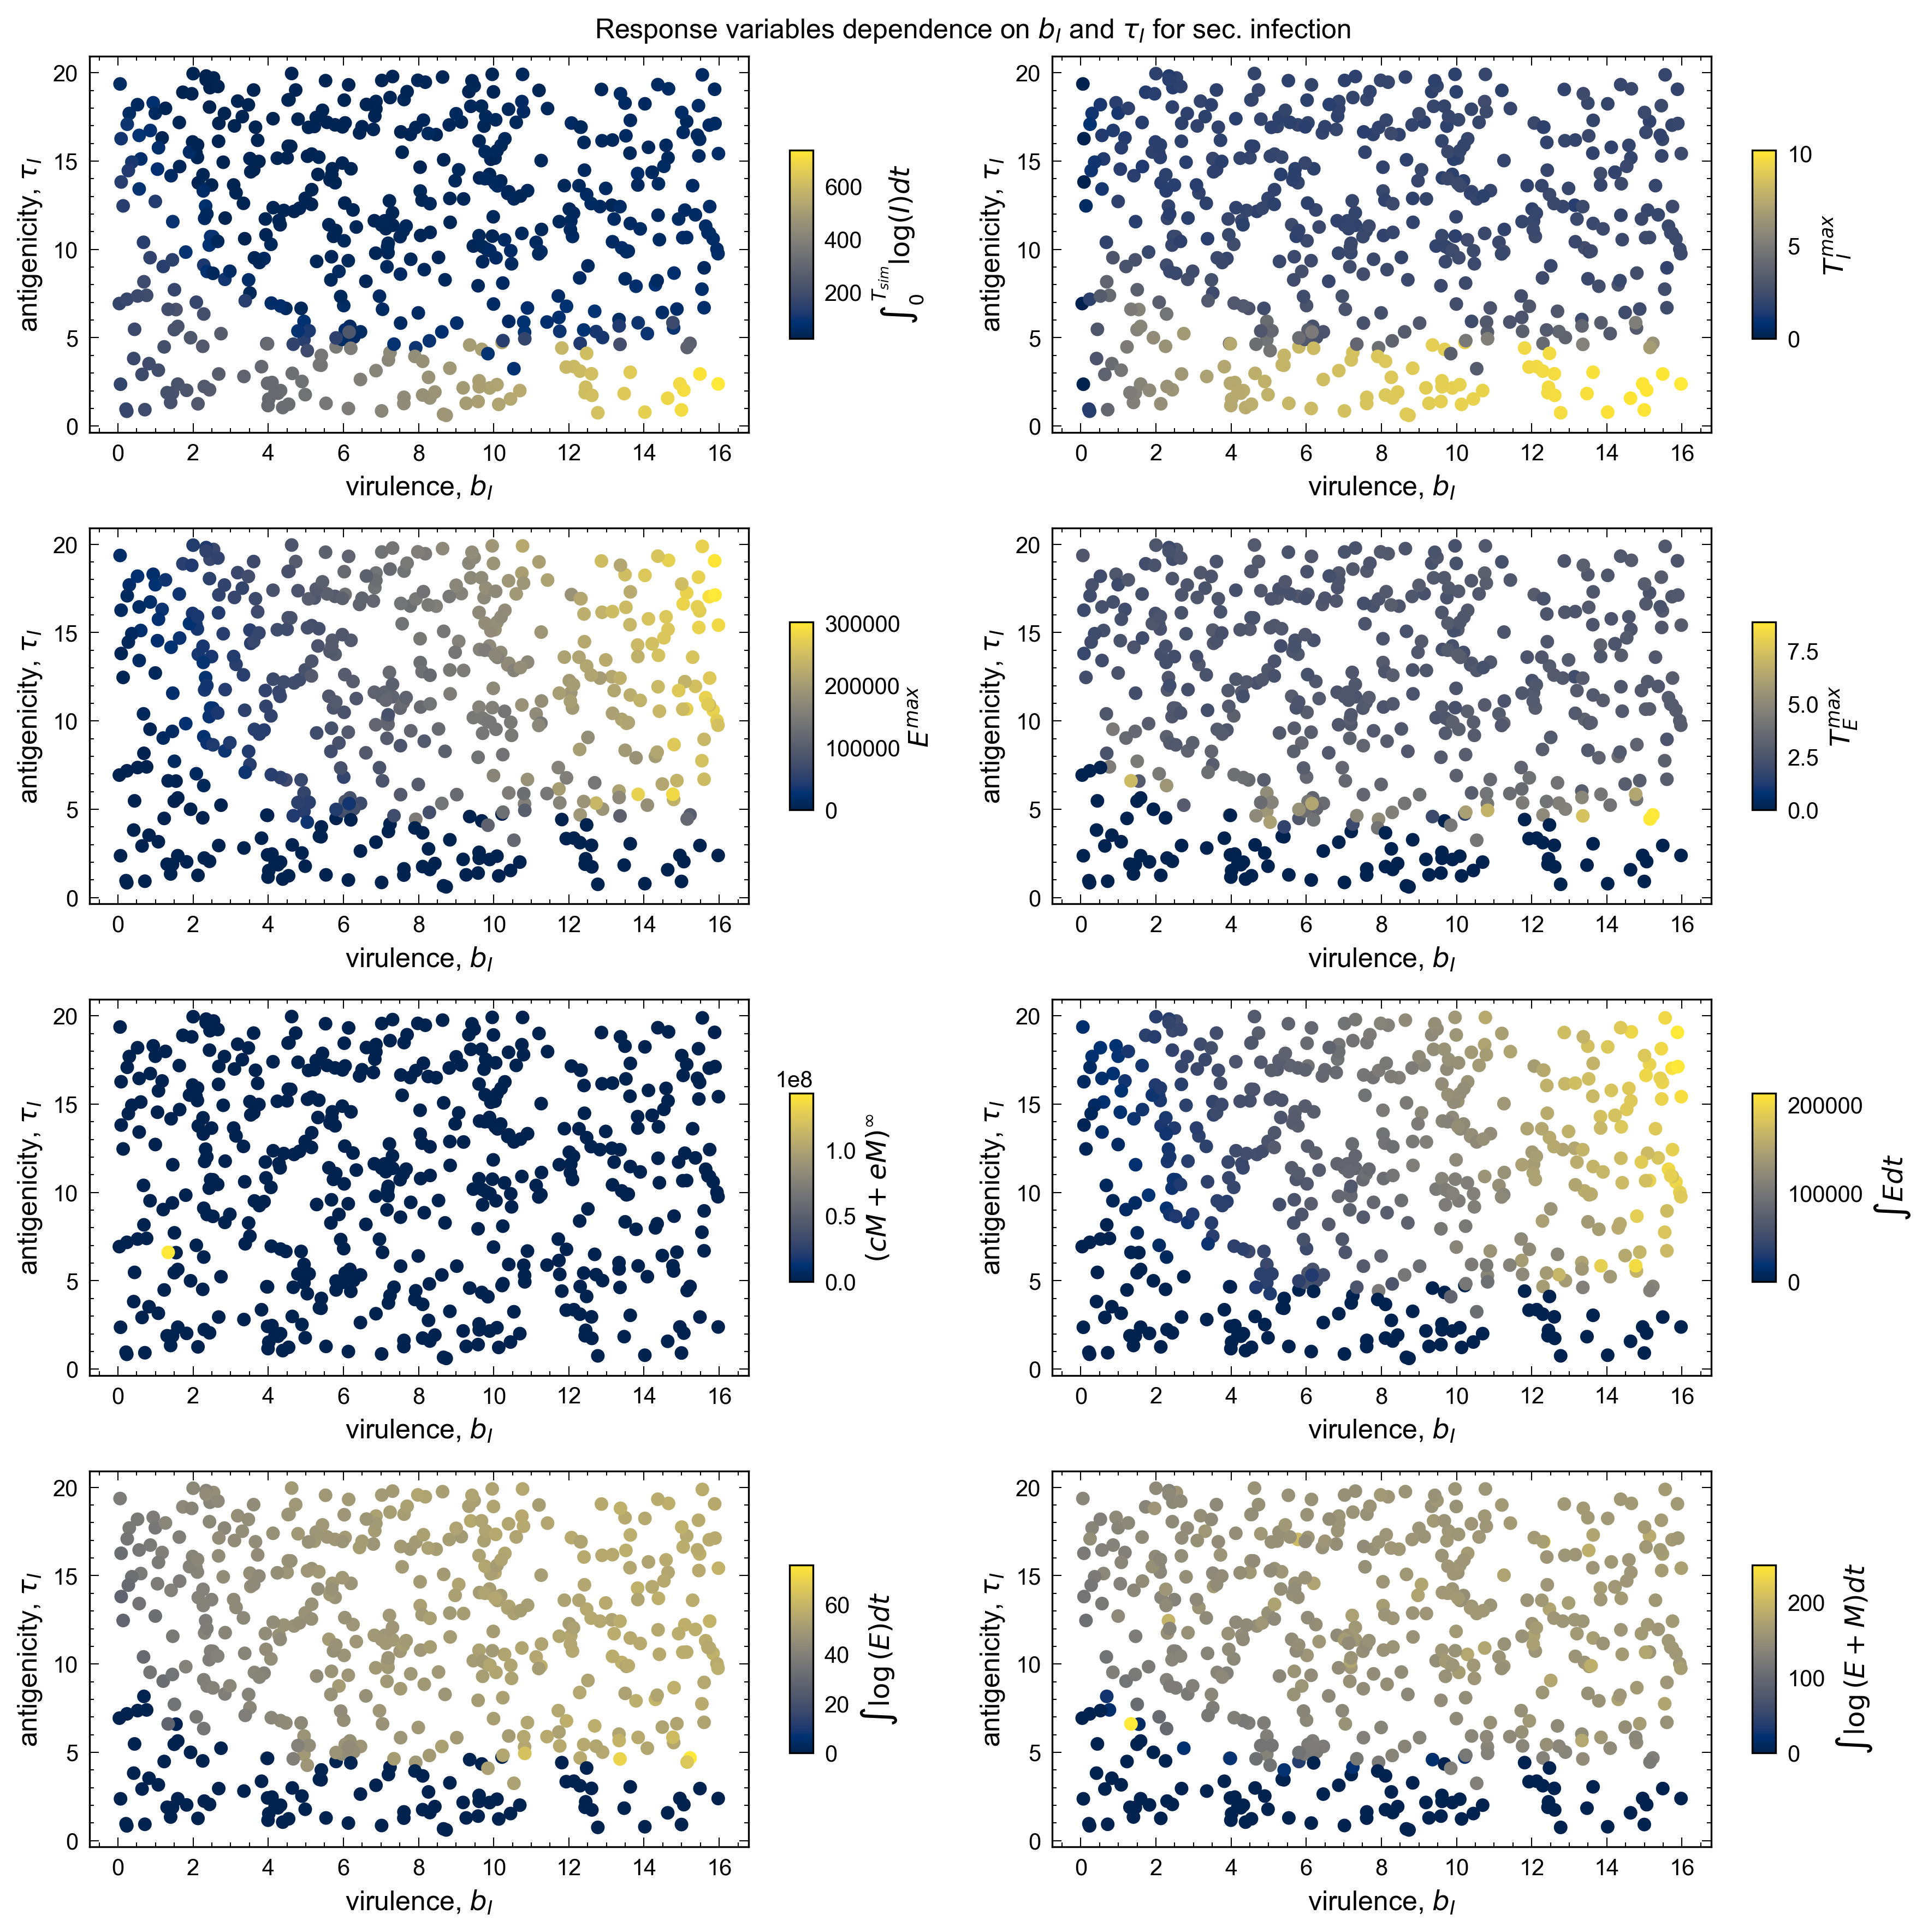

In [19]:
# plot surface plots
fig = plt.figure(figsize=(12,12),dpi = 150)

i = 1
num_points = np.minimum(run_data_Is.shape[0], 10000)

for val in stat_names[i+9:]:

    ax = fig.add_subplot(4, 2, i) #, projection='3d')
    # set the limits of the plot to the limits of the data
    img = ax.scatter(run_data_Is[:num_points, 7], run_data_Is[:num_points,8], c = run_data_Is[:num_points,i+9], cmap=plt.cm.cividis)
    ax.set(xlabel=r'virulence, $b_I$', ylabel=r'antigenicity, $\tau_I$')
    fig.colorbar(img,  shrink=0.5, aspect=8, label =val)

    i += 1
    
fig.suptitle(r'Response variables dependence on $b_I$ and $\tau_I$'+' for '+infection_type+". infection")
fig.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-distribution.png', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()

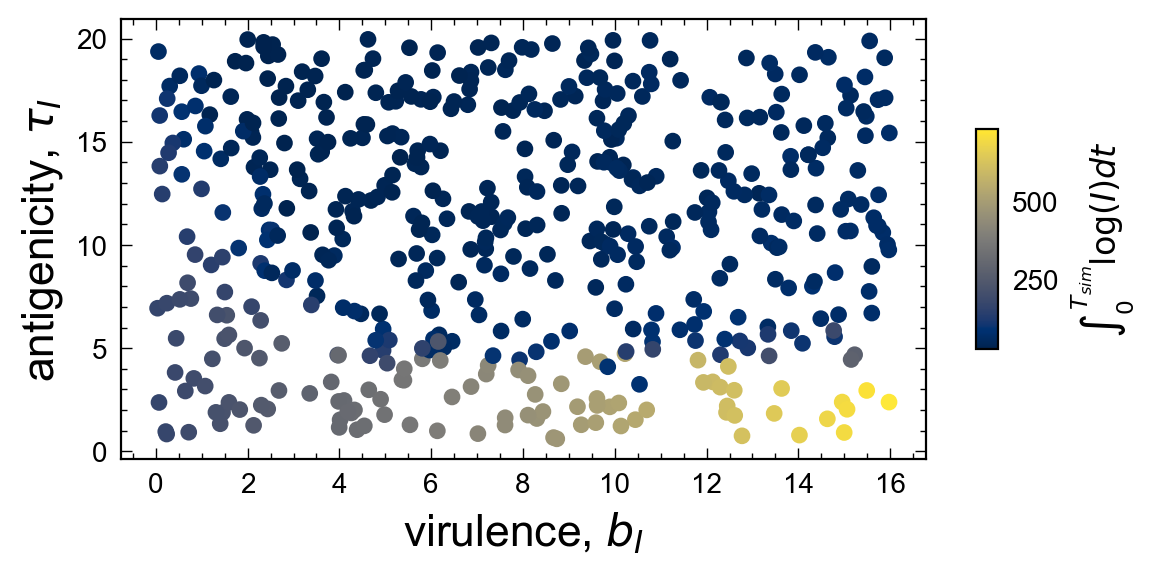

In [20]:
fig = plt.figure(figsize=(6,3))

# set the limits of the plot to the limits of the data
plt.scatter(run_data_Is[:10000,7], run_data_Is[:10000,8], c = run_data_Is[:10000, 10], cmap=plt.cm.cividis)
plt.xlabel(r'virulence, $b_I$', fontsize = 16)
plt.ylabel(r'antigenicity, $\tau_I$', fontsize = 16)
plt.colorbar(shrink=0.5, aspect=10, label =stat_names[10])
    
#fig.suptitle(r'Response variables dependence on $b_I$ and $\tau_I$'+' for '+infection_type+". infection")
fig.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'effectiveness-distribution.png', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()